In [ ]:
!wget ftp://orengoftp.biochem.ucl.ac.uk/ucbtnb4/data/inflammation-01.csv

In [ ]:
ls

In [ ]:
# This cell is doing some string manipulation

help(max)

In [ ]:
cat inflammation-01.csv

In [ ]:
open_file = open("inflammation-01.csv", "rt")
for line in open_file:
  print(line.rstrip())
open_file.close()

In [ ]:
list_example = []
list_example.append("data")
print(list_example)
for number in range(10):
  list_example.append(number)
  print(list_example)

In [ ]:
word = "phosphatase"
print(word[1])

In [ ]:
data = [0,4,4,4,5,2,6,1,0,4,4]
set_data = set(data)
print(set_data)

In [ ]:
dictionary = {}

with open("inflammation-01.csv","rt") as f:
    for i, line in enumerate(f, start=1):
        dictionary[i] = line.rstrip("\n")



dataset_size = len(dictionary)

print(dictionary[1])


In [ ]:
import numpy

Numpy load text takes two arguments, the filename and the delimiter. In this case inflammation-01.csv, which is separated by commas

In [ ]:
numpy.loadtxt()

In [ ]:
numpy.loadtxt(fname="inflammation-01.csv",delimiter=',')

The command above prints to screen, we need to save it to a variable.

In [ ]:
data = numpy.loadtxt(fname="inflammation-01.csv",delimiter=',')

In [ ]:
print(data)

We can also inspect what type our data has been stored as using "type"

In [ ]:
print(type(data))

The output tells us that data currently refers to an N-dimensional array, the functionality for which is provided by the NumPy library. These data correspond to our patients’ inflammation. The rows are the individual patients, and the columns are their daily inflammation measurements.

In [ ]:
print(data.dtype)

In [ ]:
print(data.shape)

The output tells us that the data array variable contains 60 rows and 40 columns. When we created the variable data to store our inflammation data, we did not only create the array; we also created information about the array, called members or attributes. This extra information describes data in the same way an adjective describes a noun. data.shape is an attribute of data which describes the dimensions of data. We use the same dotted notation for the attributes of variables that we use for the functions in libraries because they have the same part-and-whole relationship.

If we want to get a single number from the array, we must provide an index in square brackets after the variable name, just as we do in math when referring to an element of a matrix. Our inflammation data has two dimensions, so we will need to use two indices to refer to one specific value:

In [ ]:
print('first value in data:', data[0, 0])

In [ ]:
print('middle value in data:', data[29, 19])

The expression data[29, 19] refers to the element in the 30th row and 20th column. While this may feel intuitive, data[0, 0] can seem less so. Some programming languages—such as Fortran, MATLAB, and R—use 1-based indexing, reflecting how humans have counted for centuries. In contrast, languages in the C family (including C++, Java, Perl, and Python) use 0-based indexing because indices represent offsets from the first element: the second item is one step away from the first.

This approach aligns more closely with how computers handle arrays internally. Therefore, in Python, an M \times N array has indices ranging from 0 to M - 1 along the first axis and from 0 to N - 1 along the second. It may take some adjustment, but a useful way to think about it is that the index tells you how many steps to move from the starting position to reach the desired element.

In [ ]:
print(data[0:4, 0:10])

The slice 0:4 means “start at index 0 and continue up to, but not including, index 4.” The idea of excluding the upper bound can take some getting used to, but a helpful rule is that the number of elements in the slice equals the difference between the upper and lower indices.

Slices don’t have to begin at 0, however.

In [ ]:
print(data[5:10, 0:10])

We also don’t have to include the upper and lower bound on the slice. If we don’t include the lower bound, Python uses 0 by default; if we don’t include the upper, the slice runs to the end of the axis, and if we don’t include either (i.e., if we use ‘:’ on its own), the slice includes everything:

In [ ]:
small = data[:3, 36:]
print('small is:')
print(small)

NumPy has several useful functions that take an array as input to perform operations on its values. If we want to find the average inflammation for all patients on all days, for example, we can ask NumPy to compute data’s mean value:

In [ ]:
print(numpy.mean(data))

Let’s use three other NumPy functions to get some descriptive values about the dataset. We’ll also use multiple assignment, a convenient Python feature that will enable us to do this all in one line.

Here we’ve assigned the return value from numpy.amax(data) to the variable maxval, the value from numpy.amin(data) to minval, and so on.

In [ ]:
maxval, minval, stdval = numpy.amax(data), numpy.amin(data), numpy.std(data)

print('maximum inflammation:', maxval)
print('minimum inflammation:', minval)
print('standard deviation:', stdval)

What can a function do?

How did we know what functions NumPy has and how to use them? If you are working in Jupyter Notebook, Colab or Visual Studio Code, there is an easy way to find out. If you type the name of something followed by a dot, then you can use tab completion (e.g. type numpy. and then press Tab) to see a list of all functions and attributes that you can use. After selecting one, you can also add a question mark (e.g. numpy.cumprod?), and IPython will return an explanation of the method! This is the same as doing help(numpy.cumprod). Similarly, if you are using the “plain vanilla” Python interpreter, you can type numpy. and press the Tab key twice for a listing of what is available. You can then use the help() function to see an explanation of the function you’re interested in, for example: help(numpy.cumprod).

When analyzing data, though, we often want to look at variations in statistical values, such as the maximum inflammation per patient or the average inflammation per day. One way to do this is to create a new temporary array of the data we want, then ask it to do the calculation:

In [ ]:
patient_0 = data[0, :] # 0 on the first axis (rows), everything on the second (columns)
print('maximum inflammation for patient 0:', numpy.amax(patient_0))

We don’t actually need to store the row in a variable of its own. Instead, we can combine the selection and the function call:

In [ ]:
print('maximum inflammation for patient 2:', numpy.amax(data[2, :]))

What if we need the maximum inflammation for each patient over all days (as in the next diagram on the left) or the average for each day (as in the diagram on the right)? As the diagram below shows, we want to perform the operation across an axis:

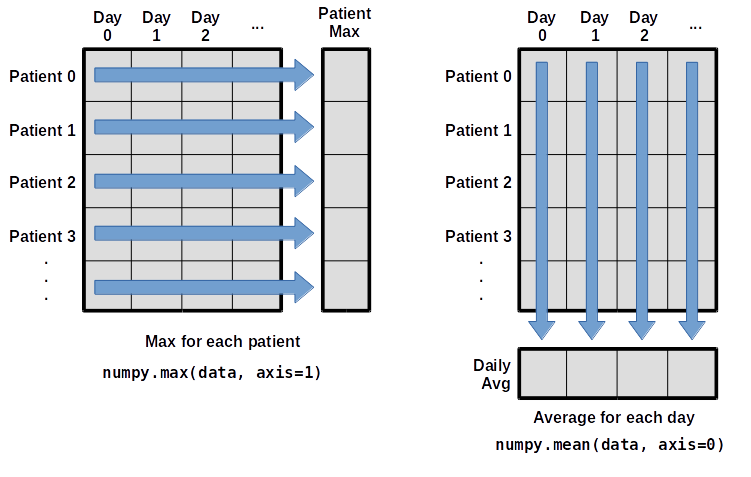

To determine the highest inflammation value recorded for each patient, you would use the max function across the columns (axis = 1). To calculate the average inflammation for each day across all patients, you would instead use the mean function down the rows (axis = 0).

Most array functions support this by allowing you to specify the axis along which the operation should be applied. In our 2D example, if we compute the maximum along axis = 1 (i.e., across columns), we obtain:

In [ ]:
print(numpy.max(data, axis=1))

As a quick check, we can inspect the shape of this array. Since we computed one maximum value per patient, we expect to see 60 values:

In [ ]:
print(numpy.max(data, axis=1).shape)

The expression (60,) tells us we have a one-dimensional array with 60 values—one maximum inflammation value for each patient.

If instead we compute the average along axis = 0 (i.e., down the rows in our 2D example), we obtain:


In [ ]:
print(numpy.mean(data, axis=0))

Check the array shape. We expect 40 averages, one for each day of the study:

In [ ]:
print(numpy.mean(data, axis=0).shape)

Similarly, we can apply the mean function to axis 1 to get the patient’s average inflammation over the duration of the study (60 values).

In [ ]:
print(numpy.mean(data, axis=1))

**SLICING STRINGS**

A section of an array is called a slice. We can take slices of character strings as well:

In [ ]:
protein = 'aldolase'
print('first three characters:', protein[0:3])
print('last three characters:', protein[3:6])

What is the value of protein[:4]? What about protein[4:]? Or protein[:]?

What is protein[-1]? What is protein[-2]?

How can we rewrite the slice for getting the last three characters of element, so that it works even if we assign a different string to element? Test your solution with the following strings: haemoglobin, petase, hi. [-3:]

Arrays can be concatenated and stacked on top of one another, using NumPy’s `vstack` and `hstack` functions for vertical and horizontal stacking, respectively.

In [ ]:
import numpy

A = numpy.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
print('A = ')
print(A)

B = numpy.hstack([A, A])
print('B = ')
print(B)

C = numpy.vstack([A, A])
print('C = ')
print(C)

Change in Inflammation

The patient data is longitudinal, meaning that each row represents a series of observations for a single individual over time. Because of this, changes in inflammation from one day to the next are meaningful and worth examining.

NumPy provides a convenient function, numpy.diff(), which computes the difference between consecutive values in an array. Let’s use it to look at how inflammation changes each day during the first week for patient 3 in our dataset.

In [ ]:
patient3_week1 = data[3, :7]
print(patient3_week1)

Calling numpy.diff(patient3_week1) would do the following calculations

In [ ]:
[ 0 - 0, 2 - 0, 0 - 2, 4 - 0, 2 - 4, 2 - 2 ]

and return the 6 difference values in a new array.

In [ ]:
numpy.diff(patient3_week1)

array([ 0.,  2., -2.,  4., -2.,  0.])

Note that the array of differences is shorter by one element (length 6).

When calling numpy.diff with a multi-dimensional array, an axis argument may be passed to the function to specify which axis to process. When applying numpy.diff to our 2D inflammation array data, which axis would we specify?

Since the row axis (0) is patients, it does not make sense to get the difference between two arbitrary patients. The column axis (1) is in days, so the difference is the change in inflammation – a meaningful concept.

In [ ]:
numpy.diff(data, axis=1)

If the shape of an individual data file is (60, 40) (60 rows and 40 columns), what would the shape of the array be after you run the diff() function and why?

How would you find the largest change in inflammation for each patient? Does it matter if the change in inflammation is an increase or a decrease?

By using the numpy.amax() function after you apply the numpy.diff() function, you will get the largest difference between days.

In [ ]:
numpy.amax(numpy.diff(data, axis=1), axis=1)

If inflammation values decrease along an axis, then the difference from one element to the next will be negative. If you are interested in the magnitude of the change and not the direction, the `numpy.absolute()` function will provide that.

Notice the difference if you get the largest absolute difference between readings.

In [ ]:
numpy.amax(numpy.absolute(numpy.diff(data, axis=1)), axis=1)

# Visualising Tabular Data

In [ ]:
import matplotlib.pyplot
image = matplotlib.pyplot.imshow(data)
matplotlib.pyplot.show()

Each row in the heat map corresponds to a patient in the clinical trial dataset, and each column represents a day. Blue pixels indicate low inflammation values, while yellow pixels indicate high values. As we can see, inflammation levels tend to rise and fall across patients over the 40-day period.

This pattern suggests that inflammation increases initially, then gradually decreases over time, eventually approaching zero toward the end of the trial.

Now let’s take a look at the average inflammation over time:

In [ ]:
ave_inflammation = numpy.mean(data, axis=0)
ave_plot = matplotlib.pyplot.plot(ave_inflammation)
matplotlib.pyplot.show()

Here, we store the average inflammation per day across all patients in the variable ave_inflammation, and then use matplotlib.pyplot to create and display a line plot of these values. The result shows a roughly linear rise followed by a decline, consistent with a delayed effect of the treatment.

Relying on the average alone is not the best way forward, so let’s also examine two additional statistics:

In [ ]:
max_plot = matplotlib.pyplot.plot(numpy.amax(data, axis=0))
matplotlib.pyplot.show()

In [ ]:
min_plot = matplotlib.pyplot.plot(numpy.amin(data, axis=0))
matplotlib.pyplot.show()

The maximum value rises and falls linearly, while the minimum seems to be a step function. Neither trend seems particularly likely, so either there’s a mistake in our calculations or something is wrong with our data. This insight would have been difficult to reach by examining the numbers themselves without visualization tools.

Grouping plots
You can group similar plots in a single figure using subplots. This script below uses a number of new commands. The function matplotlib.pyplot.figure() creates a space into which we will place all of our plots. The parameter figsize tells Python how big to make this space. Each subplot is placed into the figure using its add_subplot method. The add_subplot method takes 3 parameters. The first denotes how many total rows of subplots there are, the second parameter refers to the total number of subplot columns, and the final parameter denotes which subplot your variable is referencing (left-to-right, top-to-bottom). Each subplot is stored in a different variable (`axes1`, `axes2`, `axes3`). Once a subplot is created, the axes can be titled using the `set_xlabel()` command (or `set_ylabel()`). Here are our three plots side by side:

In [ ]:
import numpy
import matplotlib.pyplot as plt

data = numpy.loadtxt(fname='inflammation-01.csv', delimiter=',')

fig = plt.figure(figsize=(10.0, 3.0))

axes1 = fig.add_subplot(1, 3, 1)
axes2 = fig.add_subplot(1, 3, 2)
axes3 = fig.add_subplot(1, 3, 3)

# average
axes1.set_ylabel('average')
axes1.plot(numpy.mean(data, axis=0))
axes1.margins(y=0.1)

# max
axes2.set_ylabel('max')
axes2.plot(numpy.amax(data, axis=0))
axes2.margins(y=0.1)

# min
axes3.set_ylabel('min')
axes3.plot(numpy.amin(data, axis=0))
axes3.margins(y=0.1)

fig.tight_layout()

plt.savefig('inflammation.png')
plt.show()

The call to loadtxt reads our data, and the rest of the program tells the plotting library how large we want the figure to be, that we’re creating three subplots, what to draw for each one, and that we want a tight layout. (If we leave out that call to fig.tight_layout(), the graphs will actually be squeezed together more closely.)

The call to savefig stores the plot as a graphics file. This can be a convenient way to store your plots for use in other documents, web pages etc. The graphics format is automatically determined by Matplotlib from the file name ending we specify; here PNG from ‘inflammation.png’. Matplotlib supports many different graphics formats, including SVG, PDF, and JPEG.

Why do all of our plots stop just short of the upper end of our graph?

A: Because matplotlib normally sets x and y axes limits to the min and max of our data (depending on data range)

If we want to change this, we can use the set_ylim(min, max) method of each ‘axes’, for example:

In [ ]:
axes3.set_ylim(0, 20)

Update your plotting code to automatically set a more appropriate scale. (Hint: you can make use of the max and min methods to help.)

In [ ]:
axes3.set_ylabel('min')
axes3.plot(numpy.amin(data, axis=0))
axes3.set_ylim(0, 6)

In [ ]:
# Or we could use a more automated way using max

import numpy
import matplotlib.pyplot

data = numpy.loadtxt(fname='inflammation-01.csv', delimiter=',')

fig = matplotlib.pyplot.figure(figsize=(10.0, 3.0))

axes1 = fig.add_subplot(1, 3, 1)
axes2 = fig.add_subplot(1, 3, 2)
axes3 = fig.add_subplot(1, 3, 3)

axes1.set_ylabel('average')
axes1.plot(numpy.mean(data, axis=0))

axes2.set_ylabel('max')
axes2.plot(numpy.amax(data, axis=0))

min_data = numpy.amin(data, axis=0)
axes3.set_ylabel('min')
axes3.plot(min_data)
axes3.set_ylim(numpy.amin(min_data), numpy.amax(min_data) * 1.1)

fig.tight_layout()

matplotlib.pyplot.savefig('inflammation.png')
matplotlib.pyplot.show()

In the center and right subplots above, we expect all lines to look like step functions because non-integer values are not realistic for the minimum and maximum values. However, you can see that the lines are not always vertical or horizontal, and in particular the step function in the subplot on the right looks slanted. Why is this?

Because matplotlib interpolates (draws a straight line) between the points. One way to do avoid this is to use the Matplotlib drawstyle option:

In [ ]:
import numpy
import matplotlib.pyplot

data = numpy.loadtxt(fname='inflammation-01.csv', delimiter=',')

fig = matplotlib.pyplot.figure(figsize=(10.0, 3.0))

axes1 = fig.add_subplot(1, 3, 1)
axes2 = fig.add_subplot(1, 3, 2)
axes3 = fig.add_subplot(1, 3, 3)

axes1.set_ylabel('average')
axes1.plot(numpy.mean(data, axis=0), drawstyle='steps-mid')

axes2.set_ylabel('max')
axes2.plot(numpy.amax(data, axis=0), drawstyle='steps-mid')

axes3.set_ylabel('min')
axes3.plot(numpy.amin(data, axis=0), drawstyle='steps-mid')

fig.tight_layout()

matplotlib.pyplot.show()

Let's try showing the standard deviation (numpy.std) of the inflammation data for each day across all patients.

In [ ]:
std_plot = matplotlib.pyplot.plot(numpy.std(data, axis=0))
matplotlib.pyplot.show()

What can we say about this data?